---

# 8 A RISC Architecture as Target
**[Emil Sekerinski](http://www.cas.mcmaster.ca/~emil/), McMaster University,  April 2025**

---

This chapter extends the P0 compiler with code generation for the [RISC-V](https://riscv.org/) processor. Like the ARMv7 (32-bit), ARMv8 (64-bit), and Intel x64 (64-bit) processors, it is based on the principles of a [*reduced instruction set:*](https://en.wikipedia.org/wiki/Reduced_instruction_set_computer) all operations take approximately the same amount of time (length of the chain of logical gates) and can therefore be executed in a pipeline. For this, all instructions are the same length and operate mainly on *registers* distinct from the *stored memory*. This is distinct from the (less common) processors with *complex instruction sets*, like IBM z, Digital Equipment VAX, and Intel x86 (an x64 processor can emulate x86 instructions).

RISC and CISC processors are based on the *von Neumann architecture:* data and programs are stored in the same uniform memory; a *bus* connects the processor to the memory.

The characteristics of the RISC-V are:
- There are four *base instruction sets*, RV32I (32-bit registers, 32 bits address space), RV64I, RV128I, and RV32E (a subset of RV32I for small microcontrollers)
- RISC-V defines a modular architecture: a base instruction set and *extensions* (compressed instructions, multiply-divide instructions, atomic instructions, 32-bit floating point instructions, 64-bit floating point instructions, vector instructions, ...).
- Can be used from small embedded systems to parallel computers; processors don't have to support extensions.
- The instruction set is designed to allow energy-efficient implementations.
- The processor design is open-sourced.

### RISC-V Stores

<div style="float:right;margin-left:2em">


Register  | Symbolic name         | Use by convention                     | Saved by
:-------- | :---------- | :---------------                      | ------
x0        | zero        | hardwired to 0, ignores writes        | 
x1        | ra          | return address for jumps              | Caller
x2        | sp          | stack pointer                         | Callee
x3        | gp          | global pointer                        |
x4        | tp          | thread pointer                        |
x5-x6        | t0-t2          | temporary register                  | Caller
x8        | s0 _or_ fp  | saved register 0 _or_ frame pointer   | Callee
x9        | s1          | saved register                      | Callee
x10-x11       | a0-a1          | function argument _or_ return value | Caller
x12-x17       | a2-a7          | function arguments                   | Caller
x18-x27       | s2-s11          | saved registers                      | Callee
x28-x31       | t3          | temporary registers                  | Caller
pc        |      | program counter                       |

<small>Adapted from: https://github.com/riscv-non-isa/riscv-asm-manual</small>

</div>

The RISC-V processor is typical for modern real processors in that is has only two kinds of stores, *registers* and *memory*. Both are organized by *words*. A word has 4 bytes or 32 bits:

    type Byte = [0..7] → [0..1]
    type Word = [0..31] → [0..1]

The memory size, `MemSize`, is a multiple of `4K` (`K = 1024`). The memory is *byte-addressed* but organized as words; only words at addresses that are a multiple or `4` can be accessed:

    var M: [0 .. MemSize div 4) → Word

The processor's base instruction set has 32 registers of 32 bits. The *register bank* `R` is:

    var R: [0 .. 31] → Word

The register's names and typical uses are to the right. Registers are commonly referred to by `xi` rather than `i`. There is no dedicated register for the stack pointer or return address; the use of registers is by convention. The P0 compiler has its own conventions on register use. Only register `x0` is special: it is always `0`, and writes are ignored.

### RISC-V Instructions

The RISC-V instructions allow operations only on data in registers, not on data in memory. Instructions for moving words between memory and registers are:

    lw rd, n(rs)
    sw rs, n(rd)

The `lw` instruction loads memory at location `n + R[rs]` into register `R[rd]`. The `sw` instruction stores `R[rs]` to the memory at location `n + R[rd]`. The *offset* `n` must be in the interval `[0 .. 2¹²)`. The `la` instruction loads any 32-bit constant into a register; it is typically used in combination with `lw` or `sw`:

    la rd, n

sets `R[rd]` to `n`.

Operations on data in registers have uniformly *three addresses*: a destination register and two operands. One operand must be a register; the other operand can be a register or a constant. For arithmetic instructions, registers are interpreted as *unsigned* integers in binary representation or as *signed* integers in two's complement representation:

    add rd, rs1, rs2
    sub rd, rs1, rs2

sets `R[rd]` to `R[rs1] + R[rs2]` and `R[rs1] - R[rs2]` using binary addition and subtraction. There are no checks for overflow and underflow; rather, the result is as if the registers represent unsigned numbers and the operation are carried out modulo `2³²`. The *immediate* versions have the second operand as a constant:

    addi rd, rs, n
    subi rd, rs, n

sets `R[rd]` to `R[rs1] + n` and `R[rs1] - n` using binary addition and subtraction. The increment or decrement `n` must be in the interval  `[0 .. 2¹²)`.

The program counter `pc` holds the address of the next instruction in memory. It is a register that is distinct from other registers in that it can be accessed by only *branch* and *jump* instructions:

    beq rs1, rs2, n
    bne rs1, rs2, n

set `pc` to `pc + n` if `R[rs1] = R[rs2]` or `R[rs1] ≠ R[rs2]`, respectively, and sets `pc` to `pc + 4`, the next instruction, otherwise. The comparisons,

    bge rs1, rs2, n
    bgeu rs1, rs2, n

set  `pc` to `pc + n` if `R[rs1] ≥ R[rs2]`, with `bge` interpreting the registers are signed integers and `bgeu` as unsigned integers. Similarly,

    blt rs1, rs2, n
    bltu rs1, rs2, n

set `pc` to `pc + n` if `R[rs1] < R[rs2]`, with `blt` interpreting the registers are unsigned integers and `bltu` as signed integers. The unconditional jump

    jal rd, n

sets `pc` to `pc + n` and `R[rd]` to `pc + 4`, while

    jalr rd, rs, n

sets `pc` to `R[rs] + n` and `R[rd]` to `pc + 4`. Jump instructions are used for procedure calls and returns.

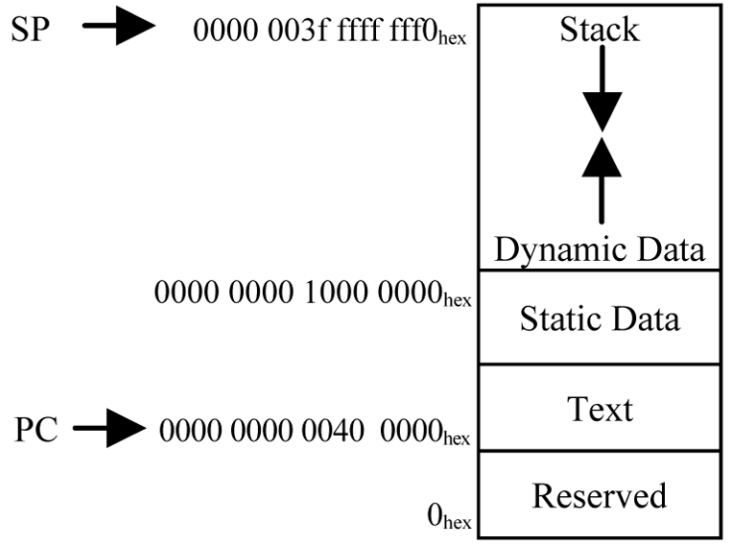

The typical memory layout is on the right:
- An area at the lower end of the address space is *reserved* for detecting null pointer dereferencing in languages with that possibility: the area is read/write protected, so an attempt to access data in that area will be interrupted.
- The *text* (historical term) area contains the code. That area should be write-protected so attempts to dereference stray pointers and maliciously modify code will be interrupted.
- The *static data* (historical term) contains constants (strings, floating-point numbers, arrays) and global variables.
- The *stack* contains the procedure call frames that contain local variables. It grows from the highest address downwards so on overflow, eventually, an attempt is made to overwrite the code, which is interrupted.
- In languages with dynamically allocated variables, the *dynamic data* shares the same area as the stack but grows bottom-up towards the top of the stack (bottom of the stack in the figure).

 For example, assuming that `x`, `y`, and `z` are global variables, and that the static data starts as `0x401000`, the P0 statement `x := y + z` can be implemented by:

<pre style="font-family:monospace;color:royalblue">
	la s5, 0x401004  ; R[s5] := 0x401004  
	lw s2, 0(s5)     ; R[s2] := M[s5]
	la s6, 0x401008  ; R[s6] := 0x401008
	lw s3, 0(s6)     ; R[s3] := M[s6]
	add s2, s2, s3   ; R[s2] := R[s2] + R[s3]
	la s10, 0x401000 ; R[s10] := 0x401000
	sw s2, 0(s10)    ; M[s10] := R[s2]
</pre>

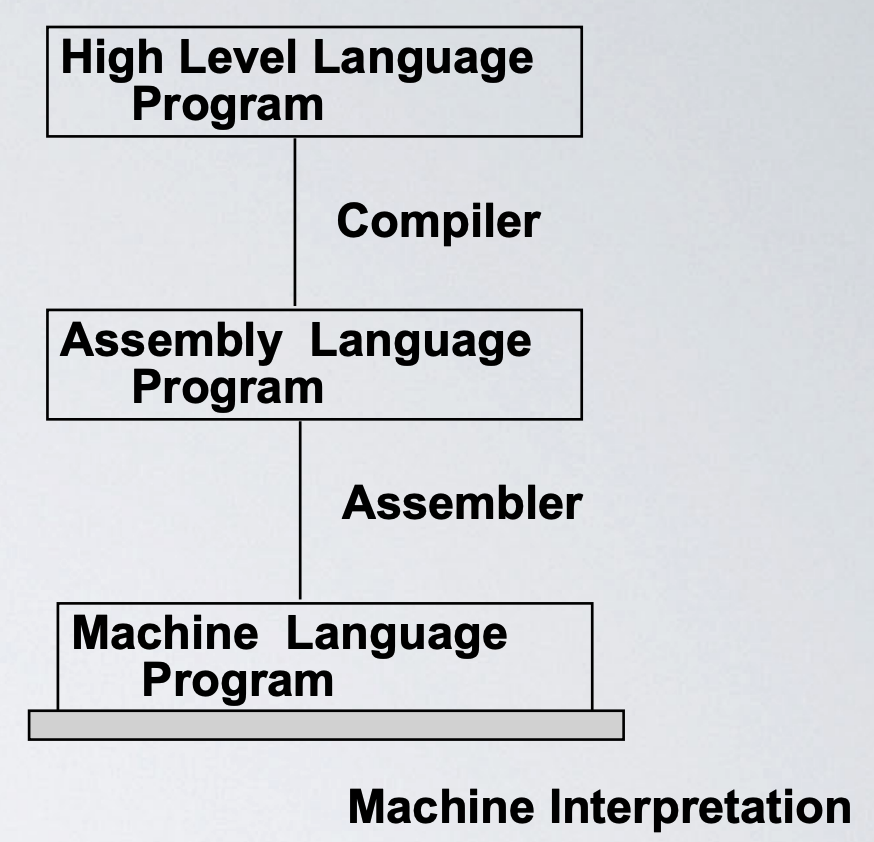

An *assembler* translates a textual machine language program into an executable binary machine language program. For this, *symbolic addresses* are substituted with real addresses according to the memory layout. The assembler also augments the binary program with information about the size of the text and static data. Continuing with the above example, for `x := y + z` the P0 compiler generates:

In [ ]:
import import_ipynb
from P0 import compileString

In [ ]:
compileString(
  """
var x, y, z: integer
program sum
    y ← read(); z ← read()
    x := y + z
    write(z)
""",
  'sum.s',
  target='riscv',
)

In [ ]:
compileString(
  """
var x, y, z: integer
program sum
    z := x × (y + 7)
""",
  target='riscv',
)

In [ ]:
!cat sum.s

RISC-V code can be executed with an RISC-V emulator, like the Python `riscemu` library. That emulator has issues with the standard method `read()` in P0. P0 programs that call `read()` have to be executed from the command line. Copy and paste the following line in a terminal:
```
python3 -m riscemu sum.s
```

A 32-bit word can be interpreted as either a signed or unsigned integer. The following functions are used to explain the effect of machine instructions:
- `𝙨 w` converts a word to a signed integer,
- `𝙪 w` converts a word to an unsigned integer,
- `𝙬 i` converts an integer to a word; the conversion is implicit below.

#### Register-Register Instructions




RV32I Arithmetic and bitwise instructions:

| Instruction         | Effect                                                 | Description              |  `func7` | `func3` | `opcode` |
|:--------------------|:-------------------------------------------------------|:-------------------------|:---------|:--------|:---------|
| `add rd, rs1, rs2`  | `R[rd], pc := (𝙪R[rs1] + 𝙪R[rs2]) 𝗺𝗼𝗱 2³², pc + 4`     | addition⁽¹⁾              | `0000000`| `000`   | `0110011` |
| `sub rd, rs1, rs2`  | `R[rd], pc := (𝙪R[rs1] – 𝙪R[rs2]) 𝗺𝗼𝗱 2³², pc + 4`     | subtraction⁽¹⁾           |
| `and rd, rs1, rs2`  | `R[rd], pc := R[rs1] & R[rs2], pc + 4`                 | bitwise and⁽²⁾           |
| `or rd, rs1, rs2`   | `R[rd], pc := R[rs1] \| R[rs2], pc + 4`                | bitwise or⁽³⁾            |
| `xor rd, rs1, rs2`  | `R[rd], pc := R[rs1] ^ R[rs2], pc + 4`                 | bitwise xor⁽⁴⁾           |
| `sll rd, rs1, rs2`  | `R[rd], pc := R[rs1] 𝘀𝗹𝗹 𝙪R[rs2], pc + 4`               | shift left⁽⁵⁾             |
| `sra rd, rs1, rs2`  | `R[rd], pc := 1 if R[rs1] 𝘀𝗿𝗮 𝙪R[rs2]) else 0, pc + 4`  | shift right arithmetic⁽⁶⁾ |
| `srl rd, rs1, rs2`  | `R[rd], pc := 1 if R[rs1] 𝘀𝗿𝗹 𝙪R[rs2]) else 0, pc + 4`  | shift right (logical)⁽⁷⁾  |
| `slt rd, rs1, rs2`  | `R[rd], pc := 1 if 𝙨R[rs1]) < 𝙨R[rs2]) else 0, pc + 4` | signed comparison         |
| `sltu rd, rs1, rs2` | `R[rd], pc := 1 if 𝙪R[rs1] < 𝙪R[rs2] else 0, pc + 4`   | unsigned comparison      |

1) Addition and subtraction interpret registers as unsigned integers. The result is also correct if the registers hold signed integers in two's complement and the result fits in a word.
2) For words `a` and `b`: `(a & b)[i] = 1 𝗶𝗳 a[i] = 1 ∧ b[i] = 1 𝗲𝗹𝘀𝗲 0`, for `0 ≤ i < 32`.
3) For words `a` and `b`: `(a | b)[i] = 1 𝗶𝗳 a[i] = 1 ∨ b[i] = 1 𝗲𝗹𝘀𝗲 0`, for `0 ≤ i < 32`.
4) For words `a` and `b`: `(a ^ b)[i] = 1 𝗶𝗳 a[i] ≠ b[i] 𝗲𝗹𝘀𝗲 0`, for `0 ≤ i < 32`.
5) For word `a`: `(a 𝘀𝗹𝗹 n)[i] = a[i – n]`, for `n ≤ i < 32` and `(a 𝘀𝗹𝗹 n)[i] = 0` for `0 ≤ i < n` and for `0 ≤ n < 32`.
6) For word `a`: `(a 𝘀𝗿𝗮 n)[i] = a[i + n]`, for `0 ≤ i < 32 – n` and `(a 𝘀𝗿𝗮 n)[i] = a[31]` for `32 – n ≤ i < 32` and for `0 ≤ n < 32`.
7) For word `a`: `(a 𝘀𝗿𝗹 n)[i] = a[i + n]`, for `0 ≤ i < 32 – n` and `(a 𝘀𝗿𝗹 n)[i] = 0` for `32 – n ≤ i < 32` and for `0 ≤ n < 32`.

RV32M Multiply Extension:

| Instruction         | Effect                                             | Description                         |
|:--------------------|:---------------------------------------------------|:------------------------------------|
| `mul rd, rs1, rs2`  | `R[rd], pc := (𝙪R[rs1] × 𝙪R[rs2]) 𝗺𝗼𝗱 2³² , pc + 4` | signed and unsigned multiplication |
| `div rd, rs1, rs2`  | `R[rd], pc := 𝙨R[rs1] 𝗱𝗶𝘃 𝙨R[rs2], pc + 4`           | signed division                    |
| `divu rd, rs1, rs2` | `R[rd], pc := 𝙪R[rs1] 𝗱𝗶𝘃 𝙪R[rs2], pc + 4`           | unsigned division                  |
| `rem rd, rs1, rs2`  | `R[rd], pc := 𝙨R[rs1] 𝗺𝗼𝗱 𝙨R[rs2], pc + 4`          | signed remainder                   |
| `remu rd, rs1, rs2` | `R[rd], pc := 𝙪R[rs1] 𝗺𝗼𝗱 𝙪R[rs2], pc + 4`          | unsigned remainder                 |

#### Register-Immediate Instructions


RV32I Arithmetic Instructions:

| Instruction         | Effect                                           | Description            |
|:--------------------|:-------------------------------------------------|:-----------------------|
| `addi rd, rs1, imm` | `R[rd], pc := R[rs1] + imm, pc + 4`              |                        |
| `andi rd, rs, imm`  | `R[rd], pc := R[rs1] & imm, pc + 4`              | bitwise and            |
| `ori rd, rs, imm`   | `R[rd], pc := R[rs1] \| imm, pc + 4`             | bitwise or             |
| `slli rd, rs, imm`  | `R[rd], pc := R[rs1] << imm, pc + 4`             | shift left             |
| `slti rd, rs, imm`  | `R[rd], pc := 1 if R[rs1] < imm else 0, pc + 4`  | signed comparison      |
| `sltiu rd, rs, imm` | `R[rd], pc := 1 if R[rs1] < imm else 0, pc + 4`  | unsigned comparison    |
| `srai rd, rs, imm`  | `R[rd], pc := 1 if R[rs1] 𝘀𝗿𝗮 imm else 0, pc + 4` | shift right arithmetic |
| `srli rd, rs, imm`  | `R[rd], pc := 1 if R[rs1] 𝘀𝗿𝗹 imm else 0, pc + 4` | shift right (logical)  |
| `subi rd, rs1, imm` | `R[rd], pc := R[rs1] – imm, pc + 4`              |                        |
| `xori rd, rs1, imm` | `R[rd], pc := R[rs1] ^ imm, pc + 4`              | bitwise xor            |

Addition and subtraction do not check for overflow and underflow.

RV32I Control Instructions:

| Instruction         | Efect                                        |                       |
|:--------------------|:---------------------------------------------|:----------------------|
| `jalr rd, rs1, imm` | `R[rd], pc := pc + 4, pc + R[s1] + imm`      | jump & link registers |
| `lb rd, rs1, imm`   | `R[rd], pc := M[R[rs1] + imm](7:0)], pc + 4` | load byte signed      |
| `lbu rd, rs1, imm`  | `R[rd], pc := M[R[rs1] + imm](7:0], pc + 4`  | load byte unsigned    |
| `lw rd, rs1, imm`   | `R[rd], pc := M[R[rs1] + imm](7:0)], pc + 4` | load word             |


### Using Registers

It is possible to use registers like a stack. The code for `y := x × (x + 7)` can be:
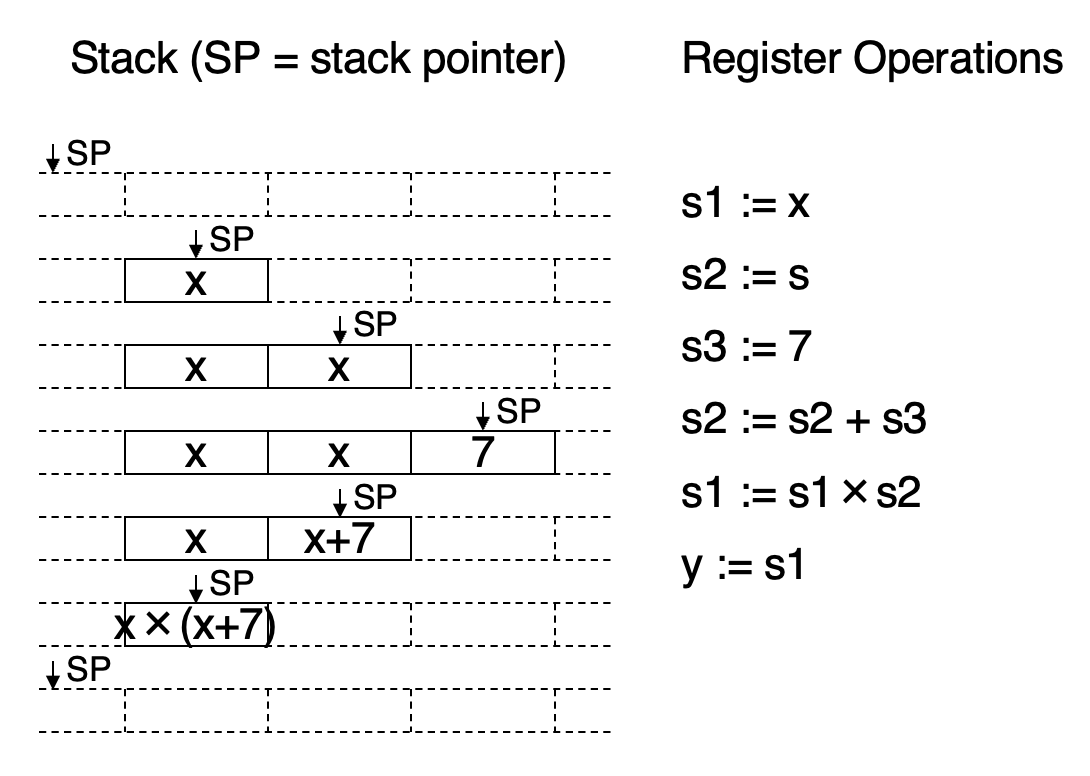
```
la t0, adr(x)
lw s1, 0(t0)
la t0, adr(x)
lw s2, 0(t0)
addi s3, zero, 7
add s2, s2, s3
mul s1, s1, s2
la t0, adr(y)
sw s1, 0(t0)
```
The compiler keeps a variable `SP` that points to the first unused register; the register bank serves as a stack:
- It does not make use of immediate addressing modes, e.g. `addi s2, zero, 7`.
- That is not an effective use of registers, e.g. `x` is loaded twice in registers.

To allow flexible use of registers, the P0 compiler maintains a set `regs` of registers in use. For RISC-V, `GPregs` are the general-purpose registers:
```Python
GPregs = {'s2','s3','s4','s5','s6','s7','s8', 's9', 's10', 's11'}
R0 = 'zero'; FP = 's0'; SP = 'sp'; RA = 'ra'
A0 = 'a0'; A1 = 'a1'; A2 = 'a2'; A3 = 'a3'
```
Set `regs` is initially `GPregs` and modified by:
```Python
def obtainReg():
    if len(regs) == 0: mark('RISC-V: out of registers')
    else: return regs.pop()

def releaseReg(r):
    if r in GPregs: regs.add(r)
```

### Translation Scheme for Expressions

The translation of an expression `E` results in the `code(E)` and the register that holds the value. The translation scheme for arithmetic expressions is:

| E           | code(E)                                 | register | condition               |
|:------------|:----------------------------------------|:---------|:------------------------|
| `x`  | `lw reg, offset(fp)`   | `reg` | if `x` local variable, `reg` is a fresh register<br> |
| `x`  | `la reg₁ x_`<br>`lw reg₂, 0(reg₁)` | `reg₂` | if `x` global variable, `reg₁, reg₂` are fresh registers|
| `n`         | `addi reg, zero, n` | `reg` | if `n` integer constant, `reg` is a fresh register |
| `E₁ × E₂`   | `code(E₁)`<br>`code(E₂)`<br>`mul reg, reg₁, reg₂` | `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register  |
| `E₁ div E₂`   | `code(E₁)`<br>`code(E₂)`<br>`div reg, reg₁, reg₂` | `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register  |
| `E₁ mod E₂`   | `code(E₁)`<br>`code(E₂)`<br>`rem reg, reg₁, reg₂`| `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register  |
| `+ E`       | `code(E)`   |  |
| `– E`       | `code(E)`<br>`sub reg, zero, reg` | `reg` | `reg` is the register of `E`   |
| `E₁ + E₂`   | `code(E₁)`<br>`code(E₂)`<br>`add reg, reg₁, reg₂` | `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register  |
| `E₁ – E₂`   | `code(E₁)`<br>`code(E₂)`<br>`sub reg, reg₁, reg₂` | `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register  |

For boolean expression, the translation scheme is analogous, except that no code is generated for the negation of a relational operation, only the relation is negated:


| E           | code(E)                                 | register | condition               |
|:------------|:----------------------------------|:------|:------------------------|
| `false`    | `addi reg, zero, 0` | `reg` | `reg` is a fresh register |
| `true`    | `addi reg, zero, 1` | `reg` | `reg` is a fresh register |
| `not E`  | `code(E)`<br>`sltiu reg, reg, 1`  | `reg` | `reg` is the register of `E`  |
| `E₁ = E₂`<br>`not(E₁ ≠ E₂)`  | `code(E₁)`<br>`code(E₂)`<br>`sub reg, reg₁, reg₂`<br>`sltiu reg, reg, 1`| `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register|
| `E₁ ≠ E₂`<br>`not(E₁ = E₂)`  | `code(E₁)`<br>`code(E₂)`<br>`sub reg, reg₁, reg₂`<br>`sltiu reg, reg, 1`<br>`xori reg, reg, 1` | `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register|
| `E₁ < E₂`<br>`not(E₁ ≥ E₂)`  | `code(E₁)`<br>`code(E₂)`<br>`slt reg, reg₁, reg₂`| `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register|
| `E₁ > E₂`<br>`not(E₁ ≤ E₂)`  | `code(E₁)`<br>`code(E₂)`<br>`slt reg, reg₂, reg₁`| `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register|
| `E₁ ≤ E₂`<br>`not(E₁ > E₂)`  | `code(E₁)`<br>`code(E₂)`<br>`slt reg, reg₂, reg₁`<br>`xori reg, reg, 1` | `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register|
| `E₁ ≥ E₂`<br>`not(E₁ < E₂)`  | `code(E₁)`<br>`code(E₂)`<br>`slt reg, reg₁, reg₂`<br>`xori reg, reg, 1` | `reg` | `reg₁` is the register of `E₁` <br> `reg₂` is the register of `E₂` <br> `reg` is a fresh register|

### Translation Scheme for Statements and Declarations

The translation scheme for P0 statements is:

| S           | code(S)                                 | condition             |
|:------------|:----------------------------------------|:------------------------|
| `x := E`  | `code(E)`<br>`sw reg, addr` | `reg` is the register of `E` <br>if `x` local, `addr` is `offset(fp)`<br> if `x` is global, `addr` is `x_`  |
| `x ← read()`  | `addi a0, zero, 0`<br>`addi a7, zero, SCALL_READINT`<br>`scall`<br>`sw a1 addr` | if `x` is local , `addr` is `offset(fp)`<br> if `x` is global, `addr` is `x_`  |
| `write(E)`  | `code(E)`<br>`addi a0, zero, 1`<br>`addi a2, zero, 4`<br>`addi a7, zero, SCALL_WRITEINT`<br>`scall`<br>`sw a1 addr` | `E` must be in register `a1`<br>if `x` is local, `addr` is `offset(fp)`<br> if `x` is global, `addr` is `x_`  |
| `writeln()`  | `addi a0, zero, 1`<br>`addi a7, zero, SCALL_WRITELN`<br>`scall` |  |
| `S₁; …; Sₙ`    | `code(S₁)` <br> `…` <br> `code(Sₙ)`                                  |                        |
| `if E then S` | `code(E)`<br>`beq reg, zero, L1`<br>`L2:`<br>  ` code(S)`<br>`L1:`<br>  `...` | `reg` is register of `E`|
| `if E then S₁ else S₂` | `code(E)`<br>`beq reg, zero, L1`<br>`L2:`<br>  `code(S₁)`<br>  `j L3`<br>`L1:`<br>  `code(S₂)`<br>`L3:`<br>  `...` | `reg` is the register of `E` |
| `while E do S` | `L1:`<br>  `code(E)`<br>  `beq reg, zero, L2`<br>`L3:`<br>  `code(S)`<br>  `j L1`<br>`L2:`<br>  `...` | `reg` is the register of `E` |

The translation scheme for declarations is:

| D                 | code(D)                             | effect                       |
|:------------------|:------------------------------------|:-----------------------|
| `var x: integer`  |                     | for local declaration, decrease `sp` to allocate space on stack  |
| `var x: boolean`  |                     | for local declaration, decrease `sp` to allocate space on stack  |
| `var x: integer`  |   `x_:   .space 4` | for global declaration |
| `var x: boolean`  | `x_:   .space 4` | for global declaration |
| `procedure p(v₁: T₁, … , vₙ: Tₙ)` <br> `D` <br> `S` |   `globl p`<br>`p:`<br>  `addi sp, sp, -n`<br>  `sw ra, (n - 4 - parsize)(sp)`<br>  `sw fp, (n - 8 - parsize)(sp)`<br>  `addi fp, sp, n - parsize`<br>  `code(D)`<br>  `code(S)`<br>  `lw ra, (n - 4 - parsize)(sp)`<br>  `lw fp, (n - 8 - parsize)(sp)`<br>  `addi sp, sp, n`<br>  `ret` | `n` is `localsize + parsize + 8`<br>rounded up to a multiple of 16<br><br>`localsize` is size of local variable<br>`parsize` is size of all parameters |

The translation scheme for a program is:

| P                 | code(P)                             |  comment                  |
|:------------------|:------------------------------------|:-----------------------|
| `D₁` <br>`program n` <br> `D₂` <br> `S` | `  .data`<br>`  code(D₁)`<br>  `  .text`<br>`.globl main`<br>`main:`<br>  `jal ra n`<br>  `addi a0, zero, 0`<br>  `addi a7, zero, 93`<br>  `scall`<br>  `.globl n`<br>`n:`<br>  `addi sp, sp, -m`<br>  `sw ra, (m-4)sp`<br>  `sw fp, (m-8)sp`<br>  `addi fp, sp, m`<br>  `code(D₂)`<br>  `code(S)`<br>  `lw ra, (m-4)sp`<br>  `lw fp, (m-8)sp`<br>  `addi sp, sp, m`<br>  `ret`| `m` is localsize + 8<br>rounded up to a multiple of 16<br><br>93 is also `SCALL_EXIT`<br>which is the exit syscall|

### Translation Scheme for Boolean Operators

In P0 boolean operators `and` and `or` evaluate conditionally:
```Pascal
p and q = if p then q else false
p or q = if p then true else q
```

The following translation scheme stores the result of a boolean expression in a register:

| E           | code(E)     | comment |                                                            
|:------------|:-----------------------------------------------------------------------|:-------------------|
| `E₁ and E₂` | `code(E₁)`<br>`beq reg1, zero, L1`<br>`L2:`<br>  `code(E₂)`<br>  `beq reg2, zero, L3`<br>`L4:`<br>  `addi reg, zero, 1`<br>  `j L5`<br>`L3, L1:`<br>  `addi reg, zero, 0`<br>`L5:`<br>  `...` | `code(E₁)` is loaded into `reg1`<br>`code(E₂)` is loaded into `reg2`<br>result is stored in `reg` |
| `E₁ or E₂`  | `code(E₁)`<br>`bne reg1, zero, L2`<br>`L1:`<br>  `code(E₂)`<br>  `beq reg2, zero, L3`<br>`L4, L2:`<br>  `addi reg, zero, 1`<br>  `j L5`<br>`L3:`<br>  `addi reg, zero, 0`<br>`L5:`<br>  `...` |`code(E₁)` is loaded into `reg1`<br>`code(E₂)` is loaded into `reg2`<br>result is stored in `reg` |

The P0 compiler implements an improved scheme that does not store intermediate results but branches to the locations where execution is to be continued right away.

### Translation Scheme for Arrays

Global arrays are statically allocated consecutively in memory.

With `A = [l .. u] → T`:

| D          | code(D)          | effect                                           |                   |
|:-----------|:-----------------|:-------------------------------------------------|:------------------|
| `var x: A` |  `x_:   .space  size(A)`   | `x.adr := x_` | global declaration|

Local arrays are dynamically allocated in memory in a stack.

With `A = [l .. u] → T`, the translation scheme for programs with local array declarations is:

| D          | code(D)          |    comment           |
|:-----------|:-----------------|:-------------------------------------------------|
| `var x: A` |  | local declaration<br>the current `sp` is decreased more<br>since current procedure allocates more space for `x` |

With `A = [l .. u] → T`, the translation scheme for array indexing and array assignment is:

| E          | code(E)                                 | comment |
|:-----------|:----------------------------------------|:--------|
| `x[E]`     |`code(E)`<br>`addi reg₁, reg₁, -x.lower`<br>`addi reg₂, zero, size(T)`<br>`mul reg₁, reg₁, reg₂`<br>`lw reg, x_(reg₁)` | `x` is global variable<br>result of `code(E)` is in `reg₁`<br> <br> <br> `x[E]` in `reg` |
| `x[E]`     |`code(E)`<br>`addi reg₁, reg₁, -x.lower`<br>`addi reg₂, zero, size(T)`<br>`mul reg₁, reg₁, reg₂`<br>`add reg₁, s0, reg₁`<br>`lw reg, -x.adr(reg₁)` | `x` is local variable<br>result of `code(E)` is in `reg₁`<br> <br> <br>`x.adr` is FP-relative address<br>`x[E]` in `reg` |

For example:

<code style="float:left;margin-left:2em">
var i, j: integer
var x: [1..5] → integer
program p
    i := x[j + 3]
</code>

<pre style="float:left;margin-left:2em">
    .data
i_:	.space 4
j_:	.space 4
x_:	.space 20
	.text
	.globl main
main:	
	jal ra, p
	addi a0, zero, 0
	addi a7, zero, 93
	scall
	.globl p
p:	
	addi sp, sp, -16
	sw ra, 12(sp)
	sw s0, 8(sp)
	addi s0, sp, 16
	la s10, j_
	lw s11, 0(s10)
	addi s9, s11, 3
	addi s9, s9, -1
	addi s8, zero, 4
	mul s9, s9, s8
	lw s4, x_(s9)
	la s2, i_
	sw s4, 0(s2)
	lw ra, 12(sp)
	lw s0, 8(sp)
	addi sp, sp, 16
	ret
</pre>

<code style="float:left;margin-left:2em">
var i, j: integer
program p
  var x: [1..5] → integer
    i := x[j + 3]
</code>

<pre style="float:left;margin-left:2em">
	.data
i_:	.space 4
j_:	.space 4
	.text
	.globl main
main:	
	jal ra, p
	addi a0, zero, 0
	addi a7, zero, 93
	scall
	.globl p
p:	
	addi sp, sp, -32
	sw ra, 28(sp)
	sw s0, 24(sp)
	addi s0, sp, 32
	la s10, j_
	lw s11, 0(s10)
	addi s9, s11, 3
	addi s9, s9, -1
	addi s8, zero, 4
	mul s9, s9, s8
	add s9, s0, s9
	lw s4, -28(s9)
	la s2, i_
	sw s4, 0(s2)
	lw ra, 28(sp)
	lw s0, 24(sp)
	addi sp, sp, 32
	ret
</pre>

| S           | code(S)                                 | comment |
|:------------|:----------------------------------------|:--------|
| `x[E] := F` | `code(E)`<br>`addi reg₁, reg₁, -x.lower`<br>`addi reg₂, zero, size(T)`<br>`mul reg₁, reg₁, reg₂`<br>`la reg₃, x_`<br>`code(F)`<br>`sw reg₄, x_(reg₃)` | `x` is global variable<br>result of `code(E)` is in `reg₁`<br> <br> <br> <br>result of `code(F)` is in `reg₄` <br> <br>|
| `x[E] := F` | `code(E)`<br>`addi reg₁, reg₁, -x.lower`<br>`addi reg₂, zero, size(T)`<br>`mul reg₁, reg₁, reg₂`<br>`add reg₁, s0, reg₁`<br>`code(F)`<br>`sw reg₄, -x.adr(reg₁)` | `x` is local variable<br>result of `code(E)` is in `reg₁`<br> <br> <br> <br>result of `code(F)` is in `reg₄` <br> <br>|

For example:

<code style="float:left;margin-left:2em">
var i, j: integer
var x: [1..5] → integer
program p
    x[i + 3] := 7
</code>

<pre style="float:left;margin-left:2em">
	.data
i_:	.space 4
j_:	.space 4
x_:	.space 20
	.text
	.globl main
main:	
	jal ra, p
	addi a0, zero, 0
	addi a7, zero, 93
	scall
	.globl p
p:	
	addi sp, sp, -16
	sw ra, 12(sp)
	sw s0, 8(sp)
	addi s0, sp, 16
	la s10, i_
	lw s11, 0(s10)
	addi s9, s11, 3
	addi s9, s9, -1
	addi s8, zero, 4
	mul s9, s9, s8
	addi s4, zero, 7
	sw s4, x_(s9)
	lw ra, 12(sp)
	lw s0, 8(sp)
	addi sp, sp, 16
	ret
</pre>

<code style="float:left;margin-left:2em">
var i, j: integer
program p
  var x: [1..5] → integer
    x[i + 3] := 7
</code>

<pre style="float:left;margin-left:2em">
	.data
i_:	.space 4
j_:	.space 4
	.text
	.globl main
main:	
	jal ra, p
	addi a0, zero, 0
	addi a7, zero, 93
	scall
	.globl p
p:	
	addi sp, sp, -32
	sw ra, 28(sp)
	sw s0, 24(sp)
	addi s0, sp, 32
	la s10, i_
	lw s11, 0(s10)
	addi s9, s11, 3
	addi s9, s9, -1
	addi s8, zero, 4
	mul s9, s9, s8
	add s9, s0, s9
	addi s4, zero, 7
	sw s4, -28(s9)
	lw ra, 28(sp)
	lw s0, 24(sp)
	addi sp, sp, 32
	ret
</pre>

### Selected RISC-V Pseudoinstructions

Pseudoinstruction            | Base Instruction(s)                                           | Meaning   | Comment
:----------------------------|:--------------------------------------------------------------|:----------|:--------|
la rd, symbol                | auipc rd, symbol[31:12]; addi rd, rd, symbol[11:0]            | Load address | With `.option nopic` (Default)
la rd, symbol                | auipc rd, symbol@GOT[31:12]; l{w\|d} rd, symbol@GOT[11:0]\(rd\) | Load address | With `.option pic`
lla rd, symbol               | auipc rd, symbol[31:12]; addi rd, rd, symbol[11:0]            | Load local address
lga rd, symbol               | auipc rd, symbol@GOT[31:12]; l{w\|d} rd, symbol@GOT[11:0]\(rd\) | Load global address
l{b\|h\|w\|d} rd, symbol     | auipc rd, symbol[31:12]; l{b\|h\|w\|d} rd, symbol[11:0]\(rd\) | Load global
l{bu\|hu\|wu} rd, symbol     | auipc rd, symbol[31:12]; l{bu\|hu\|wu} rd, symbol[11:0]\(rd\) | Load global, unsigned
s{b\|h\|w\|d} rd, symbol, rt | auipc rt, symbol[31:12]; s{b\|h\|w\|d} rd, symbol[11:0]\(rt\) | Store global
fl{w\|d} rd, symbol, rt      | auipc rt, symbol[31:12]; fl{w\|d} rd, symbol[11:0]\(rt\)      | Floating-point load global
fs{w\|d} rd, symbol, rt      | auipc rt, symbol[31:12]; fs{w\|d} rd, symbol[11:0]\(rt\)      | Floating-point store global
nop                          | addi x0, x0, 0                                                | No operation
li rd, immediate             | *Myriad sequences*                                            | Load immediate
mv rd, rs                    | addi rd, rs, 0                                                | Copy register
not rd, rs                   | xori rd, rs, -1                                               | Ones’ complement
neg rd, rs                   | sub rd, x0, rs                                                | Two’s complement
negw rd, rs                  | subw rd, x0, rs                                               | Two’s complement word
sext.b rd, rs                | slli rd, rs, XLEN - 8; srai rd, rd, XLEN - 8                  | Sign extend byte | It will expand to another instruction sequence when B extension is available*[1]
sext.h rd, rs                | slli rd, rs, XLEN - 16; srai rd, rd, XLEN - 16                | Sign extend half word | It will expand to another instruction sequence when B extension is available*[1]
sext.w rd, rs                | addiw rd, rs, 0                                               | Sign extend word
zext.b rd, rs                | andi rd, rs, 255                                              | Zero extend byte
zext.h rd, rs                | slli rd, rs, XLEN - 16; srli rd, rd, XLEN - 16                | Zero extend half word | It will expand to another instruction sequence when B extension is available*[1]
zext.w rd, rs                | slli rd, rs, XLEN - 32; srli rd, rd, XLEN - 32                | Zero extend word | It will expand to another instruction sequence when B extension is available*[1]
seqz rd, rs                  | sltiu rd, rs, 1                                               | Set if = zero
snez rd, rs                  | sltu rd, x0, rs                                               | Set if != zero
sltz rd, rs                  | slt rd, rs, x0                                                | Set if < zero
sgtz rd, rs                  | slt rd, x0, rs                                                | Set if > zero
fmv.s rd, rs                 | fsgnj.s rd, rs, rs                                            | Copy single-precision register
fabs.s rd, rs                | fsgnjx.s rd, rs, rs                                           | Single-precision absolute value
fneg.s rd, rs                | fsgnjn.s rd, rs, rs                                           | Single-precision negate
fmv.d rd, rs                 | fsgnj.d rd, rs, rs                                            | Copy double-precision register
fabs.d rd, rs                | fsgnjx.d rd, rs, rs                                           | Double-precision absolute value
fneg.d rd, rs                | fsgnjn.d rd, rs, rs                                           | Double-precision negate
beqz rs, offset              | beq rs, x0, offset                                            | Branch if = zero
bnez rs, offset              | bne rs, x0, offset                                            | Branch if != zero
blez rs, offset              | bge x0, rs, offset                                            | Branch if ≤ zero
bgez rs, offset              | bge rs, x0, offset                                            | Branch if ≥ zero
bltz rs, offset              | blt rs, x0, offset                                            | Branch if < zero
bgtz rs, offset              | blt x0, rs, offset                                            | Branch if > zero
bgt rs, rt, offset           | blt rt, rs, offset                                            | Branch if >
ble rs, rt, offset           | bge rt, rs, offset                                            | Branch if ≤
bgtu rs, rt, offset          | bltu rt, rs, offset                                           | Branch if >, unsigned
bleu rs, rt, offset          | bgeu rt, rs, offset                                           | Branch if ≤, unsigned
j offset                     | jal x0, offset                                                | Jump
jal offset                   | jal x1, offset                                                | Jump and link
jr rs                        | jalr x0, rs, 0                                                | Jump register
jalr rs                      | jalr x1, rs, 0                                                | Jump and link register
ret                          | jalr x0, x1, 0                                                | Return from subroutine
call offset                  | auipc x1, offset[31:12]; jalr x1, x1, offset[11:0]            | Call far-away subroutine
tail offset                  | auipc x6, offset[31:12]; jalr x0, x6, offset[11:0]            | Tail call far-away subroutine
fence                        | fence iorw, iorw                                              | Fence on all memory and I/O
pause                        | fence w, 0                                                    | PAUSE hint

* [1] We don't specify the code sequence when the B-extension is present, since B-extension still not ratified or frozen. We will specify the expansion sequence once it's frozen.
